# 第四课：逻辑回归与分类

## 从回归到分类

| 任务 | 输出 | 损失函数 | 例子 |
|------|------|----------|------|
| 回归 | 连续值 | MSE | 房价预测 |
| 二分类 | 概率 [0,1] | 二元交叉熵 | 垃圾邮件检测 |
| 多分类 | 概率分布 | 交叉熵 | 手写数字识别 |

## 核心思想

线性回归输出任意实数，分类需要输出概率。解决方案：
- **二分类**：Sigmoid 函数将实数映射到 [0, 1]
- **多分类**：Softmax 函数将实数向量映射为概率分布

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # 替换SimHei
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

## 1. Sigmoid 函数

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

将任意实数压缩到 (0, 1) 区间，可以理解为"属于正类的概率"。

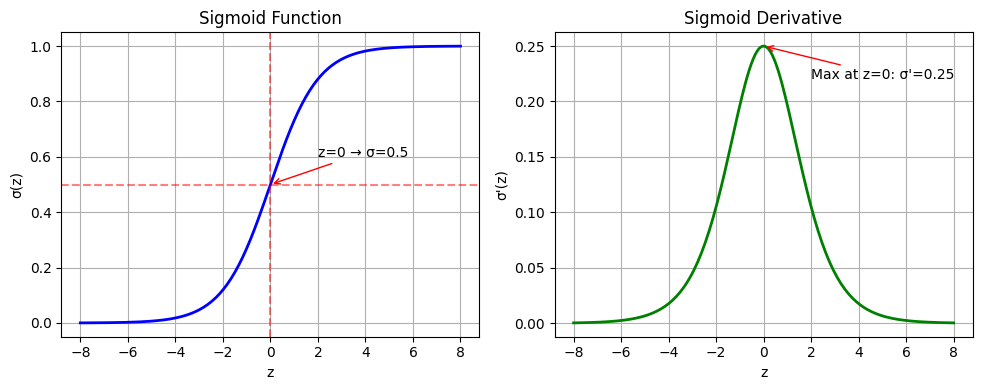

Sigmoid 的关键性质：
  σ(0) = 0.5000
  σ(大正数) → 1，σ(大负数) → 0
  σ'(z) = σ(z)(1-σ(z))，最大值为 0.25（梯度消失问题！）


In [2]:
# Sigmoid 函数可视化
z = torch.linspace(-8, 8, 200)
sigmoid_z = torch.sigmoid(z)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(z.numpy(), sigmoid_z.numpy(), 'b-', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.title('Sigmoid Function')
plt.grid(True)
plt.annotate('z=0 → σ=0.5', xy=(0, 0.5), xytext=(2, 0.6),
             arrowprops=dict(arrowstyle='->', color='red'))

# Sigmoid 的导数
sigmoid_deriv = sigmoid_z * (1 - sigmoid_z)
plt.subplot(1, 2, 2)
plt.plot(z.numpy(), sigmoid_deriv.numpy(), 'g-', linewidth=2)
plt.xlabel('z')
plt.ylabel("σ'(z)")
plt.title("Sigmoid Derivative")
plt.grid(True)
plt.annotate("Max at z=0: σ'=0.25", xy=(0, 0.25), xytext=(2, 0.22),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

print("Sigmoid 的关键性质：")
print(f"  σ(0) = {torch.sigmoid(torch.tensor(0.0)):.4f}")
print(f"  σ(大正数) → 1，σ(大负数) → 0")
print(f"  σ'(z) = σ(z)(1-σ(z))，最大值为 0.25（梯度消失问题！）")

## 2. 交叉熵损失（Cross-Entropy Loss）

### 为什么不用 MSE？

MSE + Sigmoid 会导致梯度消失（Sigmoid 导数最大才 0.25），学习极慢。

### 二元交叉熵（Binary Cross-Entropy）

$$L = -\frac{1}{N}\sum_{i=1}^{N} [y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i)]$$

- 当 $y=1$ 时：$L = -\log(\hat{y})$，预测越接近1，损失越小
- 当 $y=0$ 时：$L = -\log(1-\hat{y})$，预测越接近0，损失越小

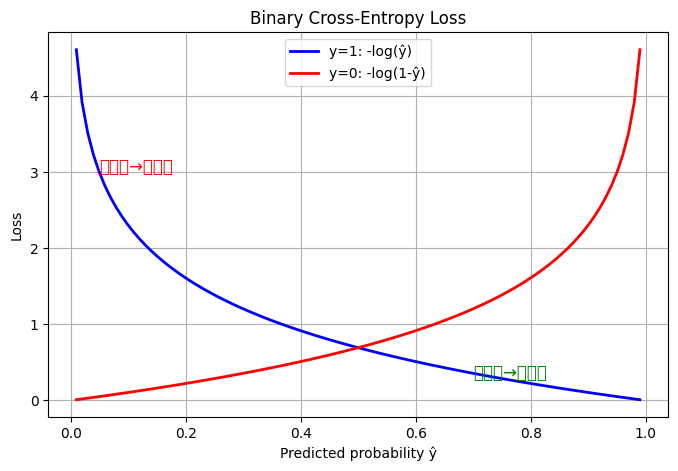

In [7]:
# 交叉熵损失可视化
p = torch.linspace(0.01, 0.99, 100)

loss_y1 = -torch.log(p)          # y=1 时的损失
loss_y0 = -torch.log(1 - p)     # y=0 时的损失

plt.figure(figsize=(8, 5))
plt.plot(p.numpy(), loss_y1.numpy(), 'b-', linewidth=2, label='y=1: -log(ŷ)')
plt.plot(p.numpy(), loss_y0.numpy(), 'r-', linewidth=2, label='y=0: -log(1-ŷ)')
plt.xlabel('Predicted probability ŷ')
plt.ylabel('Loss')
plt.title('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.annotate('预测错→损失大', xy=(0.05, 3.0), fontsize=12, color='red')
plt.annotate('预测对→损失小', xy=(0.7, 0.3), fontsize=12, color='green')
plt.show()

---
## 3. 二分类实战：逻辑回归

生成一个二分类数据集，用逻辑回归进行分类。

X shape: torch.Size([300, 2]), y shape: torch.Size([300])
类别分布: 0→150, 1→150
特征矩阵X的形状: torch.Size([300, 2])
标签向量y的形状: torch.Size([300])
类别0的数量: 150
类别1的数量: 150
前5个样本:
tensor([[ 0.1930,  0.9373],
        [ 0.3065, -0.5402],
        [-0.2514,  0.1692],
        [ 2.6217,  1.8513],
        [-1.5188, -2.5013]])
前5个标签: [0.0, 0.0, 1.0, 1.0, 0.0]


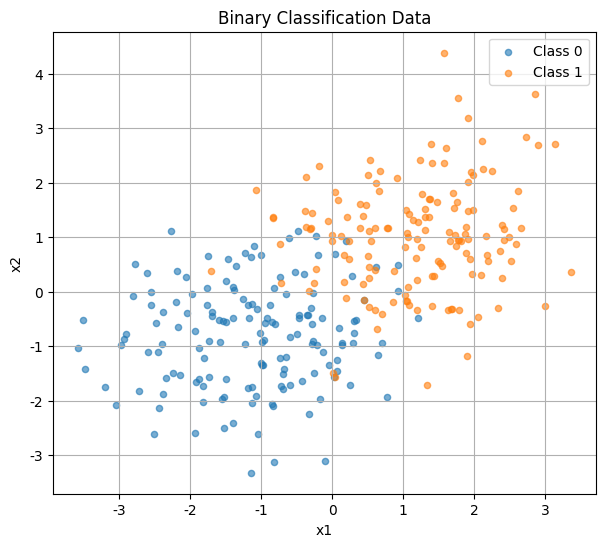

In [9]:
# 生成二分类数据
torch.manual_seed(42)
n_samples = 300

# 类别0：以 (-1, -1) 为中心
X0 = torch.randn(n_samples // 2, 2) + torch.tensor([-1.0, -1.0])
# 类别1：以 (1, 1) 为中心
X1 = torch.randn(n_samples // 2, 2) + torch.tensor([1.0, 1.0])

X = torch.cat([X0, X1], dim=0)
y = torch.cat([torch.zeros(n_samples // 2), torch.ones(n_samples // 2)])

# 打乱数据
indices = torch.randperm(n_samples)
X = X[indices]
y = y[indices]

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"类别分布: 0→{(y==0).sum()}, 1→{(y==1).sum()}")

print("特征矩阵X的形状:", X.shape)  # 输出: torch.Size([300, 2])
print("标签向量y的形状:", y.shape)  # 输出: torch.Size([300])
print("类别0的数量:", torch.sum(y == 0).item())  # 输出: 150
print("类别1的数量:", torch.sum(y == 1).item())  # 输出: 150
print("前5个样本:")
print(X[:5])
print("前5个标签:", y[:5].tolist())

# 可视化
plt.figure(figsize=(7, 6))
plt.scatter(X[y==0, 0].numpy(), X[y==0, 1].numpy(), s=20, alpha=0.6, label='Class 0')
plt.scatter(X[y==1, 0].numpy(), X[y==1, 1].numpy(), s=20, alpha=0.6, label='Class 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Binary Classification Data')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# 定义逻辑回归模型
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        logits = self.linear(x)       # 线性变换
        probs = torch.sigmoid(logits) # Sigmoid 转概率
        return probs

model = LogisticRegression(input_dim=2)
print(model)
print(f"参数: weight={model.linear.weight.data.numpy().flatten()}, bias={model.linear.bias.item():.4f}")

LogisticRegression(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)
参数: weight=[-0.2898952 -0.5058714], bias=-0.3957


In [11]:
# 训练
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.SGD(model.parameters(), lr=0.1)

y = y.unsqueeze(1)  # (300,) → (300, 1)，匹配模型输出形状

losses = []
accuracies = []

for epoch in range(200):
    probs = model(X)
    loss = criterion(probs, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # 计算准确率
    preds = (probs >= 0.5).float()
    acc = (preds == y).float().mean()
    
    losses.append(loss.item())
    accuracies.append(acc.item())
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: loss={loss.item():.4f}, accuracy={acc.item():.4f}")

print(f"\n最终参数: weight={model.linear.weight.data.numpy().flatten()}, bias={model.linear.bias.item():.4f}")

Epoch  50: loss=0.2554, accuracy=0.9233
Epoch 100: loss=0.2137, accuracy=0.9267
Epoch 150: loss=0.1999, accuracy=0.9300
Epoch 200: loss=0.1933, accuracy=0.9300

最终参数: weight=[1.6623031 1.3172187], bias=-0.1607


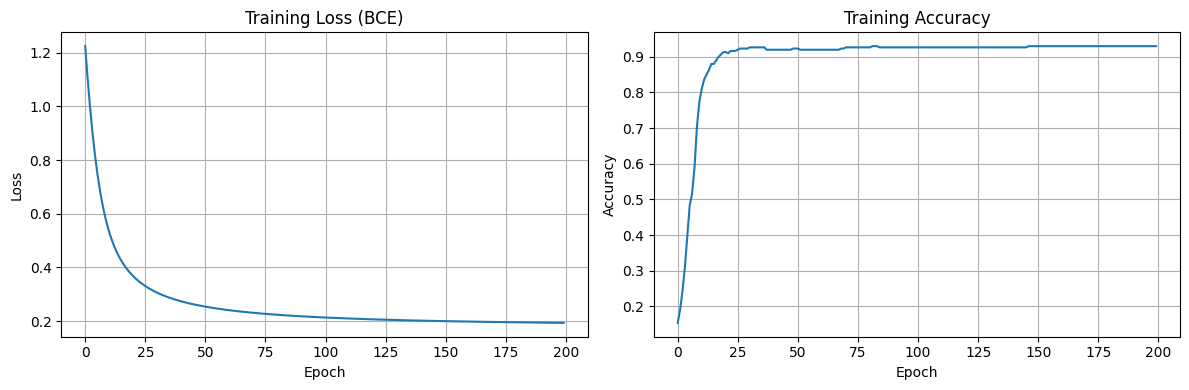

In [12]:
# 可视化训练过程
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (BCE)')
axes[0].grid(True)

axes[1].plot(accuracies)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].grid(True)

plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11396\897674277.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11396\897674277.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(y_min, y_max, h))


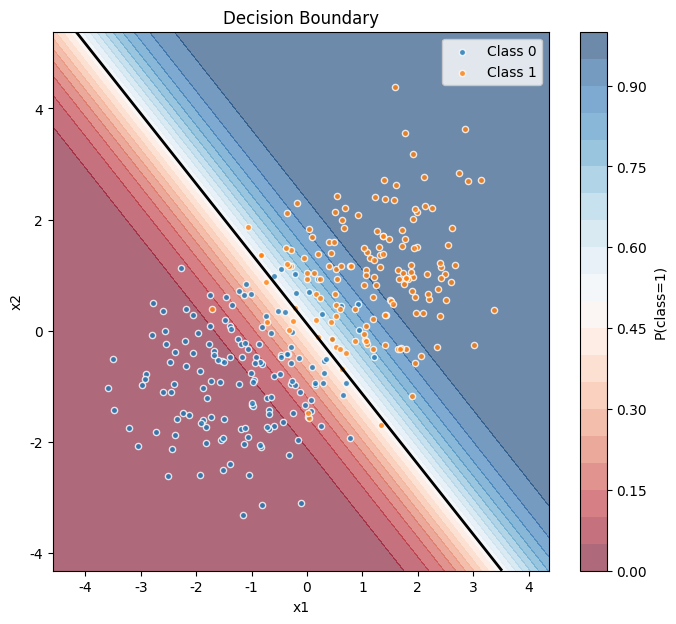

In [13]:
# 可视化决策边界
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    h = 0.05
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        probs = model(grid).reshape(xx.shape)
    
    plt.figure(figsize=(8, 7))
    plt.contourf(xx, yy, probs.numpy(), levels=20, cmap='RdBu', alpha=0.6)
    plt.colorbar(label='P(class=1)')
    plt.contour(xx, yy, probs.numpy(), levels=[0.5], colors='black', linewidths=2)
    
    y_flat = y.flatten()
    plt.scatter(X[y_flat==0, 0].numpy(), X[y_flat==0, 1].numpy(), 
                s=20, alpha=0.8, edgecolors='white', label='Class 0')
    plt.scatter(X[y_flat==1, 0].numpy(), X[y_flat==1, 1].numpy(), 
                s=20, alpha=0.8, edgecolors='white', label='Class 1')
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Decision Boundary')
    plt.legend()
    plt.show()

plot_decision_boundary(model, X, y)

---
## 4. BCEWithLogitsLoss（更稳定的写法）

上面的代码中，我们先 Sigmoid 再 BCELoss，数值上不够稳定。

PyTorch 推荐 `BCEWithLogitsLoss`，它**内部自动做 Sigmoid**，数值更稳定。

In [14]:
# 更推荐的写法：模型输出 logits，损失函数内部做 Sigmoid
class LogisticRegressionV2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        return self.linear(x)  # 直接输出 logits，不做 Sigmoid！

model_v2 = LogisticRegressionV2(input_dim=2)
criterion = nn.BCEWithLogitsLoss()  # 内部自动 Sigmoid
optimizer = optim.SGD(model_v2.parameters(), lr=0.1)

for epoch in range(200):
    logits = model_v2(X)            # 输出 logits
    loss = criterion(logits, y)     # BCEWithLogitsLoss 内部做 Sigmoid
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        acc = (preds == y).float().mean()
        print(f"Epoch {epoch+1:3d}: loss={loss.item():.4f}, accuracy={acc.item():.4f}")

print("\n✅ BCEWithLogitsLoss 是二分类的推荐写法，数值更稳定！")

Epoch  50: loss=0.2525, accuracy=0.9200
Epoch 100: loss=0.2129, accuracy=0.9233
Epoch 150: loss=0.1996, accuracy=0.9300
Epoch 200: loss=0.1932, accuracy=0.9300

✅ BCEWithLogitsLoss 是二分类的推荐写法，数值更稳定！


---
## 5. Softmax 函数与多分类

### Softmax

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

将 K 个实数转换为 K 个概率，满足：
- 每个值在 (0, 1) 之间
- 所有值之和为 1

### 交叉熵损失（多分类）

$$L = -\sum_{i=1}^{K} y_i \log(\hat{y}_i)$$

当 $y$ 是 one-hot 编码时，只有真实类别的项非零：$L = -\log(\hat{y}_{\text{true}})$

Logits: [2.0, 1.0, 0.10000000149011612]
Softmax 概率: [0.6590011715888977, 0.24243298172950745, 0.09856589138507843]
概率之和: 1.0000
预测类别: 0


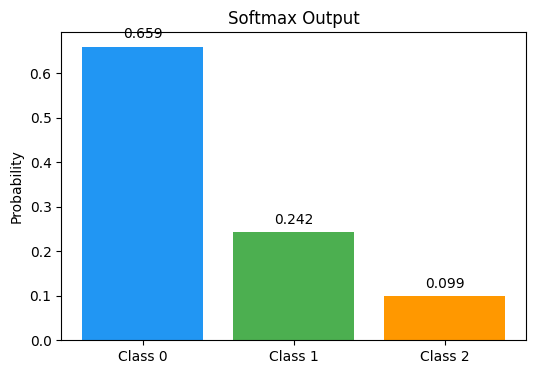

In [15]:
# Softmax 可视化
logits = torch.tensor([2.0, 1.0, 0.1])
probs = torch.softmax(logits, dim=0)

print(f"Logits: {logits.tolist()}")
print(f"Softmax 概率: {probs.tolist()}")
print(f"概率之和: {probs.sum().item():.4f}")
print(f"预测类别: {probs.argmax().item()}")

plt.figure(figsize=(6, 4))
classes = ['Class 0', 'Class 1', 'Class 2']
plt.bar(classes, probs.numpy(), color=['#2196F3', '#4CAF50', '#FF9800'])
plt.ylabel('Probability')
plt.title('Softmax Output')
for i, p in enumerate(probs):
    plt.text(i, p + 0.02, f'{p:.3f}', ha='center')
plt.show()

## 6. 多分类实战：三分类问题

X shape: torch.Size([300, 2]), y shape: torch.Size([300])
类别分布: 0→100, 1→100, 2→100


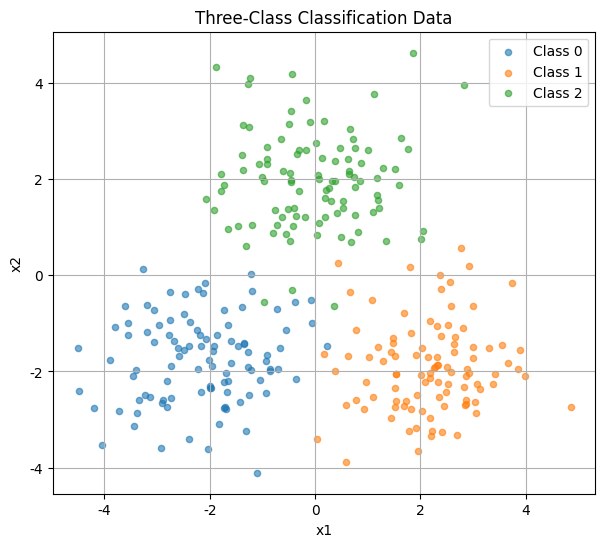

In [16]:
# 生成三分类数据
torch.manual_seed(42)
n_per_class = 100

X0 = torch.randn(n_per_class, 2) + torch.tensor([-2.0, -2.0])
X1 = torch.randn(n_per_class, 2) + torch.tensor([2.0, -2.0])
X2 = torch.randn(n_per_class, 2) + torch.tensor([0.0, 2.0])

X_multi = torch.cat([X0, X1, X2], dim=0)
y_multi = torch.cat([torch.zeros(n_per_class), 
                      torch.ones(n_per_class), 
                      2 * torch.ones(n_per_class)]).long()

# 打乱
indices = torch.randperm(len(y_multi))
X_multi = X_multi[indices]
y_multi = y_multi[indices]

print(f"X shape: {X_multi.shape}, y shape: {y_multi.shape}")
print(f"类别分布: 0→{(y_multi==0).sum()}, 1→{(y_multi==1).sum()}, 2→{(y_multi==2).sum()}")

plt.figure(figsize=(7, 6))
for c in range(3):
    mask = y_multi == c
    plt.scatter(X_multi[mask, 0].numpy(), X_multi[mask, 1].numpy(), 
                s=20, alpha=0.6, label=f'Class {c}')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Three-Class Classification Data')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# 定义多分类模型
class MultiClassModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)
    
    def forward(self, x):
        return self.linear(x)  # 输出 logits，不做 Softmax！

model_multi = MultiClassModel(input_dim=2, num_classes=3)

# ⭐ CrossEntropyLoss = LogSoftmax + NLLLoss（内部自动做 Softmax）
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_multi.parameters(), lr=0.1)

print(f"模型: {model_multi}")
print(f"损失函数: CrossEntropyLoss（内部自动 Softmax，不需要手动做）")

模型: MultiClassModel(
  (linear): Linear(in_features=2, out_features=3, bias=True)
)
损失函数: CrossEntropyLoss（内部自动 Softmax，不需要手动做）


In [18]:
# 训练
losses = []
accuracies = []

for epoch in range(200):
    logits = model_multi(X_multi)              # (300, 3)
    loss = criterion(logits, y_multi)           # y 是类别索引，不是 one-hot！
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    preds = logits.argmax(dim=1)                # 取最大值的索引
    acc = (preds == y_multi).float().mean()
    
    losses.append(loss.item())
    accuracies.append(acc.item())
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: loss={loss.item():.4f}, accuracy={acc.item():.4f}")

Epoch  50: loss=0.1528, accuracy=0.9733
Epoch 100: loss=0.1148, accuracy=0.9800
Epoch 150: loss=0.0983, accuracy=0.9767
Epoch 200: loss=0.0888, accuracy=0.9800


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11396\1665654147.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11396\1665654147.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(y_min, y_max, h))


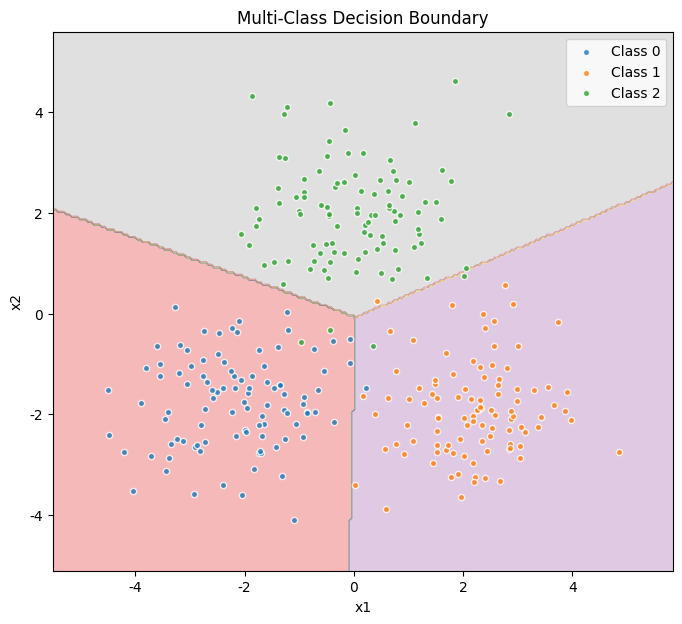

In [19]:
# 可视化多分类决策边界
def plot_multi_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    h = 0.05
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        logits = model(grid)
        probs = torch.softmax(logits, dim=1)
        pred_class = probs.argmax(dim=1).reshape(xx.shape)
    
    plt.figure(figsize=(8, 7))
    plt.contourf(xx, yy, pred_class.numpy(), alpha=0.3, cmap='Set1')
    
    for c in range(3):
        mask = y == c
        plt.scatter(X[mask, 0].numpy(), X[mask, 1].numpy(), 
                    s=20, alpha=0.8, edgecolors='white', label=f'Class {c}')
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Multi-Class Decision Boundary')
    plt.legend()
    plt.show()

plot_multi_decision_boundary(model_multi, X_multi, y_multi)

---
## 7. ⚠️ 常见易错点总结

In [ ]:
# 易错点1：损失函数和标签格式的对应关系
print("=== 损失函数 vs 标签格式 ===\n")

# 二分类
print("二分类:")
print("  BCELoss          → 标签: float (0.0 或 1.0)")
print("  BCEWithLogitsLoss → 标签: float (0.0 或 1.0)")

# 多分类
print("\n多分类:")
print("  CrossEntropyLoss → 标签: long 类别索引 (0, 1, 2, ...)，不是 one-hot！")
print("  NLLLoss          → 标签: long 类别索引，但输入需要先 LogSoftmax")

# 示例
logits = torch.tensor([[2.0, 1.0, 0.1]])
target = torch.tensor([0])  # 类别索引，不是 [1, 0, 0]！

loss = nn.CrossEntropyLoss()(logits, target)
print(f"\nCrossEntropyLoss 示例: logits={logits.tolist()}, target={target.tolist()}, loss={loss.item():.4f}")

In [ ]:
# 易错点2：模型输出和损失函数的匹配
print("=== 模型输出 vs 损失函数 ===\n")

print("二分类:")
print("  模型输出 logits + BCEWithLogitsLoss  ✅ 推荐（数值稳定）")
print("  模型输出 probs + BCELoss             ⚠️ 可以但不推荐")
print("  模型输出 logits + BCELoss            ❌ 错误！")

print("\n多分类:")
print("  模型输出 logits + CrossEntropyLoss   ✅ 推荐（数值稳定）")
print("  模型输出 probs + CrossEntropyLoss    ❌ 错误！CrossEntropyLoss 内部做 Softmax")
print("  模型输出 log_probs + NLLLoss         ✅ 可以，等价于 CrossEntropyLoss")

In [ ]:
# 易错点3：预测时的 Sigmoid/Softmax
print("=== 预测时是否需要手动 Sigmoid/Softmax？ ===\n")

model = MultiClassModel(2, 3)
test_x = torch.randn(1, 2)

with torch.no_grad():
    logits = model(test_x)
    probs = torch.softmax(logits, dim=1)
    pred_class = logits.argmax(dim=1)  # argmax 不需要 Softmax！

print(f"Logits: {logits.tolist()}")
print(f"Softmax 概率: {probs.tolist()}")
print(f"预测类别: {pred_class.item()}")
print()
print("💡 关键：argmax(logits) == argmax(softmax(logits))")
print("   所以只预测类别时，不需要做 Softmax，直接对 logits 取 argmax 即可！")
print("   但如果需要概率值（如输出置信度），则需要 Softmax。")

---
## 8. 评估指标

In [20]:
# 混淆矩阵与评估指标
from collections import Counter

def confusion_matrix(y_true, y_pred, n_classes):
    cm = torch.zeros(n_classes, n_classes, dtype=torch.long)
    for t, p in zip(y_true, y_pred):
        cm[t.long(), p.long()] += 1
    return cm

with torch.no_grad():
    logits = model_multi(X_multi)
    preds = logits.argmax(dim=1)

cm = confusion_matrix(y_multi, preds, n_classes=3)
print("混淆矩阵:")
print("         Pred 0  Pred 1  Pred 2")
for i in range(3):
    print(f"True {i}:  {cm[i].tolist()}")

# 计算每个类别的 Precision, Recall, F1
print("\n各类别指标:")
for c in range(3):
    tp = cm[c, c].item()
    fp = cm[:, c].sum().item() - tp
    fn = cm[c, :].sum().item() - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f"  Class {c}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

overall_acc = (preds == y_multi).float().mean().item()
print(f"\nOverall Accuracy: {overall_acc:.4f}")

混淆矩阵:
         Pred 0  Pred 1  Pred 2
True 0:  [99, 1, 0]
True 1:  [0, 99, 1]
True 2:  [2, 2, 96]

各类别指标:
  Class 0: Precision=0.9802, Recall=0.9900, F1=0.9851
  Class 1: Precision=0.9706, Recall=0.9900, F1=0.9802
  Class 2: Precision=0.9897, Recall=0.9600, F1=0.9746

Overall Accuracy: 0.9800


---
## 📝 第四课总结

### 核心概念

| 概念 | 公式 | 用途 |
|------|------|------|
| Sigmoid | $\sigma(z) = \frac{1}{1+e^{-z}}$ | 二分类，输出概率 |
| Softmax | $\text{softmax}(z_i) = \frac{e^{z_i}}{\sum e^{z_j}}$ | 多分类，输出概率分布 |
| BCE Loss | $-[y\log\hat{y} + (1-y)\log(1-\hat{y})]$ | 二分类损失 |
| CrossEntropy Loss | $-\sum y_i \log\hat{y}_i$ | 多分类损失 |

### 损失函数选择速查表

| 任务 | 模型输出 | 损失函数 | 标签格式 |
|------|----------|----------|----------|
| 二分类 | logits | `BCEWithLogitsLoss` ✅ | float (0/1) |
| 二分类 | probs | `BCELoss` | float (0/1) |
| 多分类 | logits | `CrossEntropyLoss` ✅ | long 类别索引 |
| 多分类 | log_probs | `NLLLoss` | long 类别索引 |

### ⚠️ 最重要的记忆点
1. **模型输出 logits，损失函数内部做 Sigmoid/Softmax**（数值稳定）
2. **CrossEntropyLoss 的标签是类别索引，不是 one-hot**
3. **预测类别时直接对 logits 取 argmax，不需要 Softmax**
4. **Sigmoid 导数最大 0.25，是梯度消失的原因之一**